## Durum Çalışması

|$x_1$|$x_2$|
|:---:|:---:|
|$4$|$11$|
|$8$|$4$|
|$13$|$5$|
|$7$|$14$|

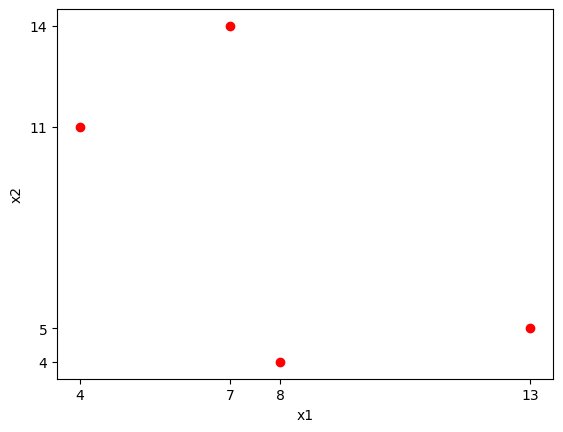

In [3]:
import matplotlib.pyplot as plt

plt.scatter([4, 8, 13, 7], [11, 4, 5, 14], color='red')
plt.xticks([4, 8, 13, 7])
plt.yticks([11, 4, 5, 14])
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

1. Kovaryans matrisinin hesaplanması için değerlerin ortalaması alınır:
$$\overline{x_1} = 8 \ \ \ \ \ \ \ \ \ \ \overline{x_2} = 8.5$$
2. Kovaryans matrisi hesaplanır:
$$\text{Covariance Matrix} \rightarrow S$$
$$S = \begin{bmatrix} \text{Cov}(x_1, x_1) & \text{Cov}(x_1, x_2)\cr \text{Cov}(x_2, x_1) & \text{Cov}(x_2, x_2) \end{bmatrix}$$

$$\text{Cov}(x_a, x_b) = \frac{1}{N-1} \sum_{k=1}^N (x_{ak} - \overline{x_a}) \cdot (x_{bk} - \overline{x_b})$$
*Burada $N$ sample sayısına denk gelir.*

$$\text{Cov}(x_1, x_2) = \frac{1}{3} \left[(4-8)^2 + (8-8)^2 + (13-8)^2 + (7-8)^2\right] = 14$$
$$\downarrow$$
$$S = \begin{bmatrix}14 & -11 \cr -11 & 23\end{bmatrix}$$

3. Kovaryans matrisinin *eigen value*'ları hesaplanır:
$$\text{det}(S - \lambda I) = 0$$
*$I$ birim matrisidir. Örn: $\begin{bmatrix}1&0\cr 0&1\end{bmatrix}$*
$$\downarrow$$
$$\left|\begin{bmatrix}14 & -11 \\ -11 & 23\end{bmatrix} - \begin{bmatrix}\lambda & 0 \\ 0 & \lambda\end{bmatrix}\right|$$
$$\downarrow$$
$$\begin{vmatrix}14-\lambda & -11 \\ -11 & 23-\lambda\end{vmatrix}$$
$$\downarrow$$
$$\left[(14-\lambda)\cdot(23-\lambda)\right] - (-11 \cdot -11)$$
$$\lambda^2 - 37\lambda + 201 = 0$$
$$\lambda = \begin{bmatrix}30.3 \\ 6.6\end{bmatrix}$$

4. Hesaplanan *eigen value*'leri kullanarak *eigen vector* hesaplanır:

*$U$ hesaplanılacak eigen vector vector olacak şekilde*

$$(S-\lambda I)\cdot U = \begin{bmatrix}0 \\ 0\end{bmatrix}$$
$$\downarrow$$
$$U=\begin{bmatrix}11 \\ 14-\lambda \end{bmatrix}$$

5. Temel bileşen hesaplanır:

*Hesaplama sırasında, sırasıyla yüksek olan $\lambda$ değerleri kullanılır $(30.3)$. Burada kullanılan eigen vektörü ünit bazlı kullanmamız gerektiği için önce eigen vektörün ünit değeri bulunur.*

$$\left||U|\right| = \sqrt{11^2 + (14-\lambda)^2} = 19.7$$
$$\text{unit eigen vector} = \frac{U}{\left||U|\right|}$$
$$\downarrow$$
$$\frac{\begin{bmatrix}11 \\ 14-\lambda \end{bmatrix}}{19.7} = \begin{bmatrix}0.55 \\ -0.83\end{bmatrix} = e_1$$

6. PCA hesaplanır:

$$e_1^T \cdot \begin{bmatrix}x_{1k}-\overline{x_1} \\ x_{2k}-\overline{x_2}\end{bmatrix}$$
$$\downarrow$$
$$\begin{bmatrix}0.55 & -0.83\end{bmatrix} \cdot \begin{bmatrix}4 & -8 \\ 11 & -8.5\end{bmatrix} = -4.3$$
*Diğer $x_1$ ve $x_2$ değerleri için de hesaplandığında:*

|$x_1$|$x_2$|$\text{PCA}$|
|:---:|:---:|:---:|
|$4$|$11$|$-4.3$|
|$8$|$4$|$3.7$|
|$13$|$5$|$5.6$|
|$7$|$14$|$5.1$|

![Eigen Value 1](ev1.png)
![Eigen Value 2](ev2.png)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Wine.csv")
X = data.iloc[:,:13].values
Y = data.iloc[:,13].values

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.33, random_state=0)

from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(x_train)
X_test = sc.transform(x_test)

## PCA:

*Important: When applying PCA, don't fit the object for the second time.*

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train_pca,y_train)

classifier2 = LogisticRegression(random_state=0)
classifier2.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [5]:
y_pred_pca = classifier.predict(X_test_pca)
y_pred = classifier2.predict(X_test)

In [6]:
from sklearn.metrics import confusion_matrix

### PCA Results Confusion Matrix:

In [8]:
confusion_matrix(y_test, y_pred_pca)

array([[20,  0,  0],
       [ 2, 22,  0],
       [ 0,  0, 15]], dtype=int64)

### Non-PCA Results Confusion Matrix:

In [9]:
confusion_matrix(y_test,y_pred)

array([[20,  0,  0],
       [ 0, 24,  0],
       [ 0,  0, 15]], dtype=int64)

### PCA & Non-PCA Confusion Matrix:

In [10]:
confusion_matrix(y_pred_pca, y_pred)

array([[20,  2,  0],
       [ 0, 22,  0],
       [ 0,  0, 15]], dtype=int64)